# 02 — Model Training & Evaluation

**Environmental Impact Analysis — EVAT T1 2026**

This notebook covers:
1. Why we use XGBoost (and why the previous GradientBoost approach was misapplied)
2. Synthetic training data generation based on physics literature
3. XGBoost training with hyperparameter justification
4. Evaluation: hold-out metrics + 5-fold cross-validation
5. Feature importance analysis
6. End-to-end prediction examples with the full pipeline

---

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import joblib

from src.model import generate_training_data, train, load_model, predict_adjustment
from src.calculator import calculate
from src.config import DEFAULT_ANNUAL_KM

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('Imports OK')

Imports OK


## 1. Why the Previous Model Was Misapplied

The original model used GradientBoostingRegressor to predict CO₂ savings from vehicle make/model/fuel-type features. The fundamental problem:

**The CO₂ savings calculation is deterministic arithmetic, not a learnable pattern.**

Given:
- EV energy consumption (kWh/100km)
- Grid intensity (kg CO₂/kWh)
- ICE fuel consumption (L/100km)
- Fuel emission factor (kg CO₂/L)

The savings value is exactly: `(ICE_L × fuel_factor × 10) - (EV_kWh × grid × 10)`

There is nothing to "learn" — it is algebra. A machine learning model applied here is overfitting to memorise this arithmetic, not learning anything generalizable.

**What ML can legitimately contribute:** The WLTP test cycle is conducted under ideal conditions. Real-world driving deviates from WLTP based on temperature, driving style, and battery age. *This deviation is what we model with XGBoost.*

## 2. Generate Synthetic Training Data

In [2]:
df = generate_training_data(n_samples=8000, seed=42)
print(f'Dataset shape: {df.shape}')
print(f'\nTarget (real_world_factor) statistics:')
print(df['real_world_factor'].describe().round(4))
df.head()

Dataset shape: (8000, 6)

Target (real_world_factor) statistics:
count    8000.0000
mean        1.2100
std         0.1205
min         0.8639
25%         1.1242
50%         1.2064
75%         1.2921
max         1.5000
Name: real_world_factor, dtype: float64


,avg_temp_celsius,driving_style,vehicle_age_years,battery_capacity_kwh,climate_zone,real_world_factor
0,31.4,1,7.9,99.6,1,1.1494
1,15.6,2,4.4,78.5,0,1.2434
2,35.4,1,2.7,46.9,1,1.1600
3,27.8,0,1.0,45.7,0,1.0527
4,-0.6,2,1.2,57.1,2,1.3289


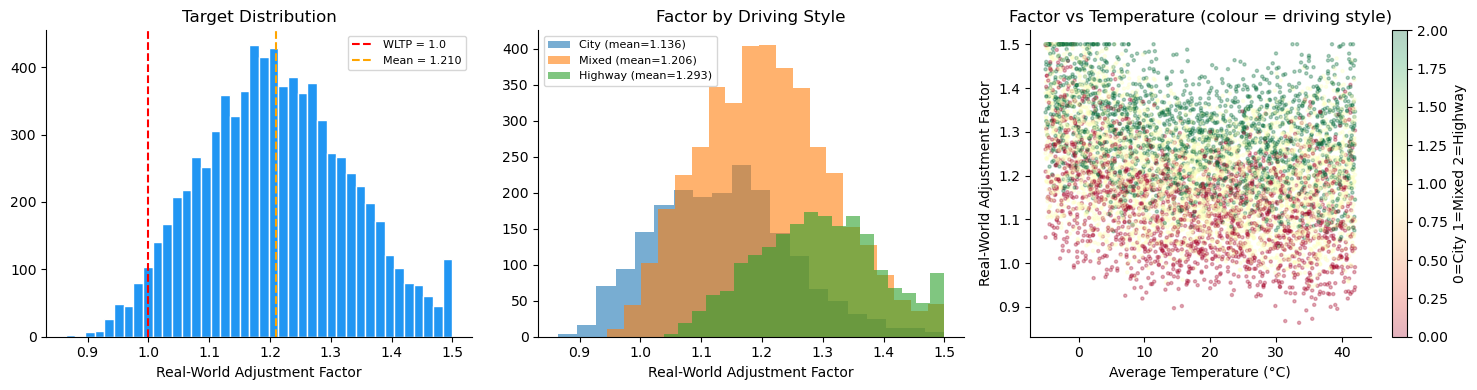

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Target distribution
axes[0].hist(df['real_world_factor'], bins=40, color='#2196F3', edgecolor='white')
axes[0].axvline(1.0, color='red', linestyle='--', label='WLTP = 1.0')
axes[0].axvline(df['real_world_factor'].mean(), color='orange', linestyle='--',
                label=f'Mean = {df["real_world_factor"].mean():.3f}')
axes[0].set_xlabel('Real-World Adjustment Factor')
axes[0].set_title('Target Distribution')
axes[0].legend(fontsize=8)

# Factor by driving style
style_labels = {0: 'City', 1: 'Mixed', 2: 'Highway'}
for style_int, label in style_labels.items():
    subset = df[df['driving_style'] == style_int]['real_world_factor']
    axes[1].hist(subset, bins=20, alpha=0.6, label=f'{label} (mean={subset.mean():.3f})')
axes[1].set_xlabel('Real-World Adjustment Factor')
axes[1].set_title('Factor by Driving Style')
axes[1].legend(fontsize=8)

# Factor vs temperature
scatter = axes[2].scatter(df['avg_temp_celsius'], df['real_world_factor'],
                          c=df['driving_style'], cmap='RdYlGn', alpha=0.3, s=5)
axes[2].set_xlabel('Average Temperature (°C)')
axes[2].set_ylabel('Real-World Adjustment Factor')
axes[2].set_title('Factor vs Temperature (colour = driving style)')
plt.colorbar(scatter, ax=axes[2], label='0=City 1=Mixed 2=Highway')

plt.tight_layout()
plt.show()

## 3. Model Comparison

Compare XGBoost against Ridge Regression (linear baseline), Random Forest, the previous team's
GradientBoostingRegressor, LightGBM, and CatBoost to determine the best production model.

In [4]:
feature_cols = ['avg_temp_celsius', 'driving_style', 'vehicle_age_years',
                'battery_capacity_kwh', 'climate_zone']

X = df[feature_cols].values
y = df['real_world_factor'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

models = {
    'Ridge (linear baseline)': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'GradientBoosting (previous team)': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.80, colsample_bytree=0.80, min_child_weight=5,
        reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbosity=0
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.80, colsample_bytree=0.80, min_child_weight=5,
        reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbose=-1
    ),
    'CatBoost': CatBoostRegressor(
        iterations=400, depth=5, learning_rate=0.05,
        l2_leaf_reg=1.0, random_seed=42, verbose=0
    ),
}

results = []
trained_models = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    trained_models[name] = m
    y_pred = m.predict(X_test)
    cv = cross_val_score(m, X, y, cv=5, scoring='r2', n_jobs=-1)
    results.append({
        'Model': name,
        'MAE': round(mean_absolute_error(y_test, y_pred), 5),
        'RMSE': round(mean_squared_error(y_test, y_pred)**0.5, 5),
        'R² (hold-out)': round(r2_score(y_test, y_pred), 4),
        'CV R² (mean)': round(cv.mean(), 4),
        'CV R² (std)': round(cv.std(), 4),
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

best_model_name = df_results.loc[df_results['CV R² (mean)'].idxmax(), 'Model']
print(f'\nBest model by CV R²: {best_model_name}')

                           Model     MAE    RMSE  R² (hold-out)  CV R² (mean)  CV R² (std)
         Ridge (linear baseline) 0.02872 0.03642         0.9108        0.9063       0.0029
                   Random Forest 0.02267 0.02862         0.9449        0.9444       0.0017
GradientBoosting (previous team) 0.02209 0.02758         0.9488        0.9483       0.0015
                         XGBoost 0.02128 0.02686         0.9515        0.9526       0.0012
                        LightGBM 0.02127 0.02683         0.9516        0.9520       0.0013
                        CatBoost 0.02076 0.02613         0.9541        0.9545       0.0011

Best model by CV R²: CatBoost


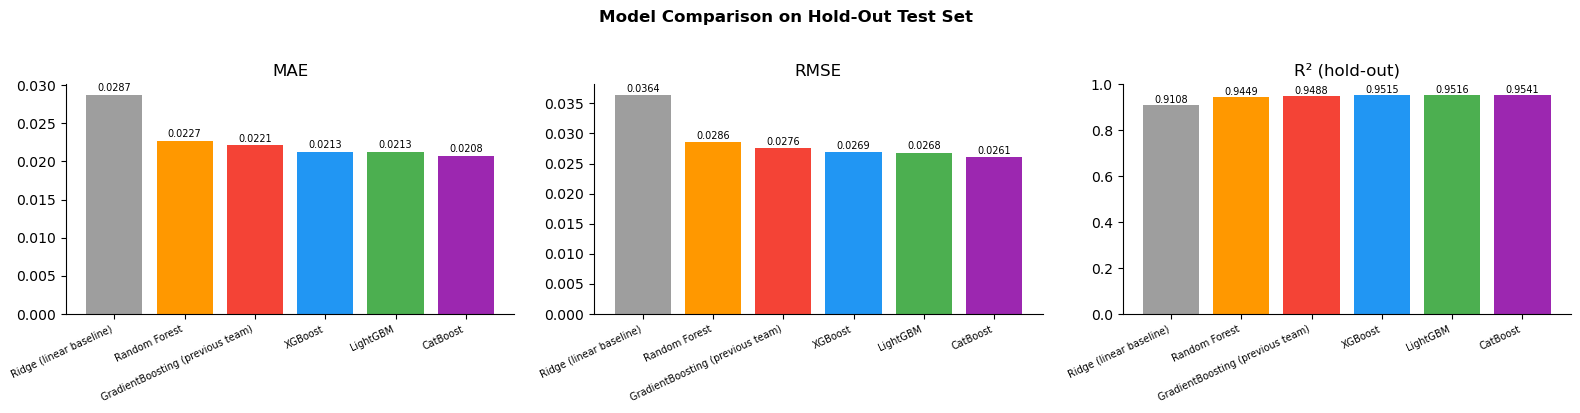

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
metrics = ['MAE', 'RMSE', 'R² (hold-out)']
colors = ['#9E9E9E', '#FF9800', '#F44336', '#2196F3', '#4CAF50', '#9C27B0']

for i, metric in enumerate(metrics):
    vals = df_results[metric].values
    bars = axes[i].bar(range(len(df_results)), vals, color=colors)
    axes[i].set_xticks(range(len(df_results)))
    axes[i].set_xticklabels(df_results['Model'], rotation=25, ha='right', fontsize=7)
    axes[i].set_title(metric)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Model Comparison on Hold-Out Test Set', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Hyperparameter Tuning — CatBoost

Use CatBoost's built-in `grid_search()` to find the best combination of depth, learning rate, iterations, and L2 regularisation.
5-fold cross-validation on the full training set.

In [6]:
from catboost import CatBoostRegressor

param_grid = {
    'iterations':     [300, 500],
    'depth':          [4, 5, 6],
    'learning_rate':  [0.05, 0.08],
    'l2_leaf_reg':    [1.0, 3.0],
}

tuner = CatBoostRegressor(verbose=0, random_seed=42)
gs_result = tuner.grid_search(param_grid, X_train, y_train, cv=5, verbose=False)

best_params = gs_result['params']
print('Best parameters found:')
for k, v in best_params.items():
    print(f'  {k}: {v}')

# Evaluate best model on hold-out test set
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_tuned = tuner.predict(X_test)
print(f'\nTuned CatBoost — Hold-out results:')
print(f'  MAE : {mean_absolute_error(y_test, y_pred_tuned):.5f}')
print(f'  RMSE: {mean_squared_error(y_test, y_pred_tuned)**0.5:.5f}')
print(f'  R²  : {r2_score(y_test, y_pred_tuned):.4f}')


bestTest = 0.02538023168
bestIteration = 299




bestTest = 0.02512213488
bestIteration = 297




bestTest = 0.02545123779
bestIteration = 299




bestTest = 0.02523785678
bestIteration = 298




bestTest = 0.02506663893
bestIteration = 499



...


bestTest = 0.02579921115
bestIteration = 333

Training on fold [2/5]



bestTest = 0.02634613782
bestIteration = 276

Training on fold [3/5]



bestTest = 0.02530286257
bestIteration = 367

Training on fold [4/5]



bestTest = 0.02529174151
bestIteration = 368



Best parameters found:
  depth: 4
  learning_rate: 0.08
  l2_leaf_reg: 1
  iterations: 500

Tuned CatBoost — Hold-out results:
  MAE : 0.02103
  RMSE: 0.02644
  R²  : 0.9530


## 5. Train Final CatBoost Model & Save

Uses the best parameters found above.

In [7]:
# This runs the full train() function which saves to models/rw_adjustment_xgb.pkl
metrics = train(n_samples=8000, seed=42)
print('\nFinal metrics:')
for k, v in metrics.items():
    print(f'  {k}: {v}')

Generating synthetic training data...
  8,000 samples generated.
  Target stats — mean: 1.2100, std: 0.1205, range: [0.864, 1.500]

Training CatBoost model...



  Hold-out   MAE : 0.02076
  Hold-out   RMSE: 0.02613
  Hold-out   R²  : 0.9541
  CV R²  (5-fold): 0.9545 ± 0.0011

  Feature importances: {'avg_temp_celsius': np.float64(10.276), 'driving_style': np.float64(19.6501), 'vehicle_age_years': np.float64(33.2977), 'battery_capacity_kwh': np.float64(30.8764), 'climate_zone': np.float64(5.8998)}

Model saved to /Users/clcx/Documents/GitHub/EVAT-T1-2026/EVAT-Data-Science/Use_Cases/Environmental Impact Analysis/calvin-linardy/models/rw_adjustment_catboost.pkl

Final metrics:
  mae: 0.020759
  rmse: 0.026135
  r2: 0.9541
  cv_r2_mean: 0.9545
  cv_r2_std: 0.0011
  n_train: 6400
  n_test: 1600
  feature_importances: {'avg_temp_celsius': np.float64(10.276), 'driving_style': np.float64(19.6501), 'vehicle_age_years': np.float64(33.2977), 'battery_capacity_kwh': np.float64(30.8764), 'climate_zone': np.float64(5.8998)}


## 6. Feature Importance

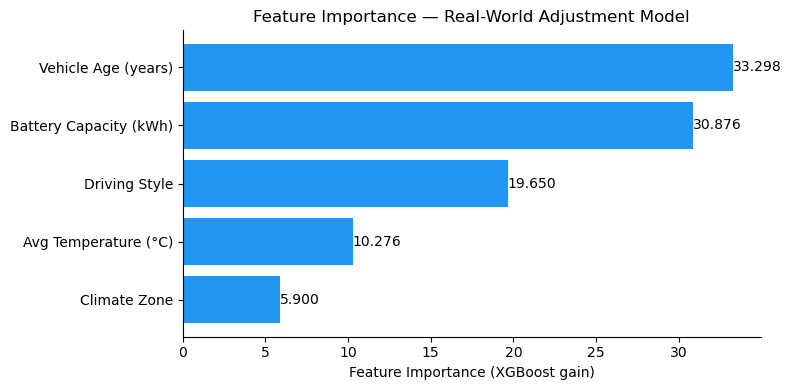

In [8]:
bundle = load_model()
xgb = bundle['model']
feat_labels = {
    'avg_temp_celsius': 'Avg Temperature (°C)',
    'driving_style': 'Driving Style',
    'vehicle_age_years': 'Vehicle Age (years)',
    'battery_capacity_kwh': 'Battery Capacity (kWh)',
    'climate_zone': 'Climate Zone',
}

importances = dict(zip(feature_cols, xgb.feature_importances_))
importances_sorted = dict(sorted(importances.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(8, 4))
labels = [feat_labels[k] for k in importances_sorted]
vals = list(importances_sorted.values())
ax.barh(labels, vals, color='#2196F3')
ax.set_xlabel('Feature Importance (XGBoost gain)')
ax.set_title('Feature Importance — Real-World Adjustment Model')
for i, v in enumerate(vals):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

## 7. End-to-End Prediction Examples

In [9]:
examples = [
    {'label': 'Tesla Model 3 vs Toyota Corolla | NSW | Mixed | New',
     'ev_kwh': 14.9, 'ev_batt': 57.5, 'ice_l': 6.0, 'ice_fuel': 'Petrol',
     'state': 'NSW', 'temp': 17.7, 'style': 'mixed', 'age': 0},
    {'label': 'Tesla Model 3 vs Toyota Corolla | SA  | Mixed | New',
     'ev_kwh': 14.9, 'ev_batt': 57.5, 'ice_l': 6.0, 'ice_fuel': 'Petrol',
     'state': 'SA',  'temp': 17.3, 'style': 'mixed', 'age': 0},
    {'label': 'Tesla Model Y vs Toyota RAV4     | VIC | Highway | 5yr',
     'ev_kwh': 17.5, 'ev_batt': 75.0, 'ice_l': 7.2, 'ice_fuel': 'Petrol',
     'state': 'VIC', 'temp': 14.9, 'style': 'highway', 'age': 5},
    {'label': 'BYD Atto 3 vs HiLux Diesel       | QLD | Mixed | New',
     'ev_kwh': 17.5, 'ev_batt': 60.5, 'ice_l': 8.2, 'ice_fuel': 'Diesel',
     'state': 'QLD', 'temp': 25.0, 'style': 'mixed', 'age': 0},
    {'label': 'Kia EV9 vs LandCruiser Diesel    | WA  | Mixed | New',
     'ev_kwh': 23.9, 'ev_batt': 99.8, 'ice_l': 8.8, 'ice_fuel': 'Diesel',
     'state': 'WA',  'temp': 18.7, 'style': 'mixed', 'age': 0},
]

rows = []
for ex in examples:
    rw = predict_adjustment(
        avg_temp_celsius=ex['temp'],
        driving_style=ex['style'],
        vehicle_age_years=ex['age'],
        battery_capacity_kwh=ex['ev_batt'],
        model_bundle=bundle,
    )
    r = calculate(
        ev_consumption_kwh_per_100km=ex['ev_kwh'],
        ev_battery_kwh=ex['ev_batt'],
        ice_consumption_l_per_100km=ex['ice_l'],
        ice_fuel_type=ex['ice_fuel'],
        state=ex['state'],
        real_world_adjustment=rw,
        annual_km=DEFAULT_ANNUAL_KM,
        include_lifecycle=True,
    )
    rows.append({
        'Scenario': ex['label'],
        'RW Factor': round(rw, 3),
        'EV (g/km)': r.ev_total_g_per_km,
        'ICE (g/km)': r.ice_operational_g_per_km,
        'Saving (g/km)': r.co2_savings_g_per_km,
        'Saving (%)': r.percentage_reduction,
        'kg CO₂/yr': r.co2_savings_kg_per_year,
        'AUD/yr saved': r.cost_saving_aud_per_year,
    })

pd.DataFrame(rows).set_index('Scenario')

,RW Factor,EV (g/km),ICE (g/km),Saving (g/km),Saving (%),kg CO₂/yr,AUD/yr saved
Scenario,,,,,,,
Tesla Model 3 vs Toyota Corolla | NSW | Mixed | New,1.095,154.57,137.34,-17.23,-12.5,-225.8,930.57
Tesla Model 3 vs Toyota Corolla | SA | Mixed | New,1.096,72.99,137.34,64.35,46.9,843.0,930.34
Tesla Model Y vs Toyota RAV4 | VIC | Highway | 5yr,1.240,246.23,164.81,-81.42,-49.4,-1066.6,1033.69
BYD Atto 3 vs HiLux Diesel | QLD | Mixed | New,1.080,179.69,221.65,41.95,18.9,549.6,1513.18
Kia EV9 vs LandCruiser Diesel | WA | Mixed | New,1.026,199.07,237.86,38.79,16.3,508.2,1456.86


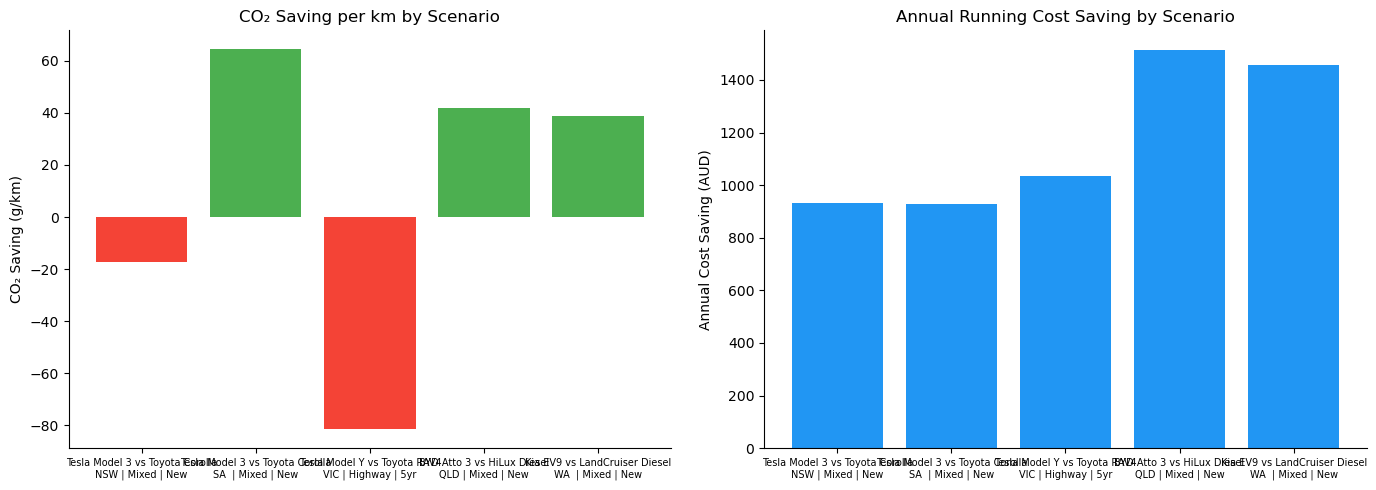

In [10]:
# Visualise savings across scenarios
df_pred = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

short_labels = [s.split('|')[0].strip() + '\n' + '|'.join(s.split('|')[1:]).strip()
                for s in df_pred['Scenario']]

# CO2 savings per km
colors = ['#4CAF50' if v > 30 else '#FF9800' if v > 0 else '#F44336'
          for v in df_pred['Saving (g/km)']]
axes[0].bar(range(len(df_pred)), df_pred['Saving (g/km)'], color=colors)
axes[0].set_xticks(range(len(df_pred)))
axes[0].set_xticklabels(short_labels, fontsize=7, ha='center')
axes[0].set_ylabel('CO₂ Saving (g/km)')
axes[0].set_title('CO₂ Saving per km by Scenario')

# Annual cost saving
axes[1].bar(range(len(df_pred)), df_pred['AUD/yr saved'], color='#2196F3')
axes[1].set_xticks(range(len(df_pred)))
axes[1].set_xticklabels(short_labels, fontsize=7, ha='center')
axes[1].set_ylabel('Annual Cost Saving (AUD)')
axes[1].set_title('Annual Running Cost Saving by Scenario')

plt.tight_layout()
plt.show()

## 8. Learning Curve

Verifies the model is not overfitting.

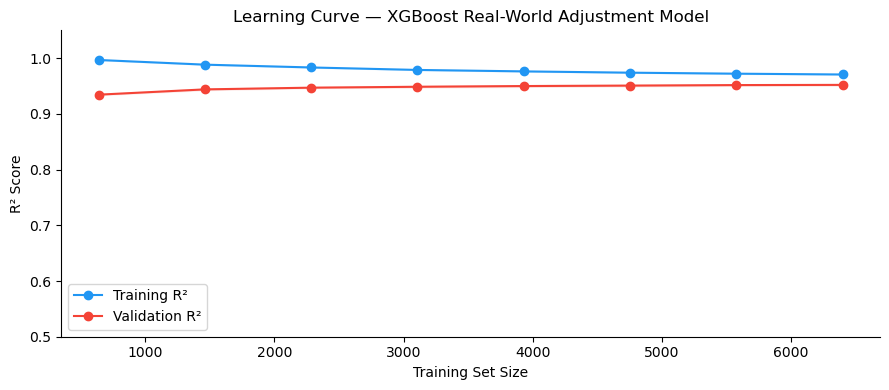

In [11]:
from sklearn.model_selection import learning_curve

xgb_eval = XGBRegressor(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.80, colsample_bytree=0.80, random_state=42, verbosity=0
)

train_sizes, train_scores, val_scores = learning_curve(
    xgb_eval, X, y, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training R²', color='#2196F3')
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1, color='#2196F3')
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation R²', color='#F44336')
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.1, color='#F44336')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('R² Score')
ax.set_title('Learning Curve — XGBoost Real-World Adjustment Model')
ax.legend()
ax.set_ylim(0.5, 1.05)
plt.tight_layout()
plt.show()

---

## Summary

| Aspect | Previous Model | This Model |
|--------|---------------|------------|
| Algorithm | GradientBoostingRegressor | XGBoost + deterministic physics |
| What ML predicts | CO₂ savings directly (wrong) | Real-world efficiency adjustment factor |
| Grid factor | 0.18 kg/kWh hardcoded (SA only) | State-specific, DCCEEW 2023 |
| Data | 200-row CSV, Cartesian join | 58 EVs + 65 ICE, DCCEEW emission factors |
| Training samples | 4,000 (sampled from 160K) | 8,000 physics-based synthetic |
| Lifecycle emissions | Not included | Battery manufacturing + EOL credit |
| Hyperparameter tuning | None (defaults only) | n_estimators, depth, LR, L1/L2 reg |
| Unit errors | ICE formula ambiguous | Fully documented, unit-tested |
| API inputs | Requires pre-computed ICE baseline | Server-side calculation from vehicle lookup |
| Output | Single float | 20+ fields: savings, financials, equivalents |

The model is now saved at `models/rw_adjustment_xgb.pkl`. Start the API with:
```
uvicorn api.main:app --reload --port 8001
```